In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [4]:
np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [27]:
# Daten erzeugen
n_points = 20
sigma = 0.1
t_np = np.sort(np.random.uniform(0.5, 2.0, size=n_points))
y_exact_np = 3.0 * np.exp(-2 * t_np)
y_noisy_np = y_exact_np + np.random.normal(0.0, sigma, n_points)


# Die Daten in 2 Dimmension umwandeln 
t_data = torch.from_numpy(t_np).float().reshape(-1, 1).to(device)
y_noisy = torch.from_numpy(y_noisy_np).float().reshape(-1, 1).to(device)

In [28]:
# --- Modell ---
class TNet(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.l1 = nn.Linear(1, hidden)
        self.l2 = nn.Linear(hidden, hidden)
        self.l3 = nn.Linear(hidden, 1)
        self.act = nn.Tanh()

        # Xavier Initialization — gut für tanh Netze. Verhindert vanishing gradients.
        nn.init.xavier_uniform_(self.l1.weight); nn.init.zeros_(self.l1.bias)
        nn.init.xavier_uniform_(self.l2.weight); nn.init.zeros_(self.l2.bias)
        nn.init.xavier_uniform_(self.l3.weight); nn.init.zeros_(self.l3.bias)

    def forward(self, x):
        x = self.act(self.l1(x))
        x = self.act(self.l2(x))
        return self.l3(x)

model = TNet().to(device)
mse = nn.MSELoss()

In [ ]:
# --- Losses ---
def pinn_losses(model, t_data, y_noisy, t_phys, ic_value=3.0):
    # 1) Data Loss
    y_hat = model(t_data)
    data_loss = mse(y_hat, y_noisy)

    # 2) Physics Loss: dy/dt + 2y = 0
    t_phys_req = t_phys.clone().detach().requires_grad_(True).to(device)
    y_phys = model(t_phys_req)
    dy_dt = torch.autograd.grad(
        outputs=y_phys,
        inputs=t_phys_req,
        grad_outputs=torch.ones_like(y_phys),
        create_graph=True
    )[0]
    residual = dy_dt + 2.0 * y_phys # Der Vergleich passiert hier
    physics_loss = mse(residual, torch.zeros_like(residual))

    # 3) IC Loss: y(0) = 3
    t0 = torch.zeros(1, 1, device=device)
    y0_hat = model(t0)
    ic_loss = mse(y0_hat, torch.tensor([[ic_value]], dtype=torch.float32, device=device))

    # Die Lambda fehlen
    total = data_loss + physics_loss + ic_loss
    return total, data_loss.detach(), physics_loss.detach(), ic_loss.detach()

In [30]:
# --- Training ---
epochs = 2000
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)

# t_phys sind Kollokationspunkte — gleichmäßig verteilt weil die Physik überall gelten muss:
t_phys = torch.linspace(0.0, 2.0, steps=200).reshape(-1, 1).to(device)

for ep in range(1, epochs + 1):
    optimizer.zero_grad()
    total, dL, pL, icL = pinn_losses(model, t_data, y_noisy, t_phys)
    total.backward()
    optimizer.step()
    if ep % 100 == 0:
        print(f"epoch {ep:4d} | total {total.item():.6f} | data {dL.item():.6f} | phys {pL.item():.6f} | ic {icL.item():.6f}")


epoch  100 | total 0.120586 | data 0.102455 | phys 0.018131 | ic 8.082973
epoch  200 | total 0.116573 | data 0.098217 | phys 0.018356 | ic 7.666230
epoch  300 | total 0.108009 | data 0.091322 | phys 0.016688 | ic 6.922085
epoch  400 | total 0.079935 | data 0.067928 | phys 0.012007 | ic 5.003834
epoch  500 | total 0.042411 | data 0.034415 | phys 0.007996 | ic 2.144264
epoch  600 | total 0.013945 | data 0.012369 | phys 0.001576 | ic 0.201208
epoch  700 | total 0.009351 | data 0.008693 | phys 0.000658 | ic 0.003624
epoch  800 | total 0.008835 | data 0.008458 | phys 0.000376 | ic 0.000760
epoch  900 | total 0.008642 | data 0.008455 | phys 0.000187 | ic 0.004062
epoch 1000 | total 0.008876 | data 0.008386 | phys 0.000490 | ic 0.005030
epoch 1100 | total 0.008534 | data 0.008439 | phys 0.000095 | ic 0.006600
epoch 1200 | total 0.008507 | data 0.008435 | phys 0.000071 | ic 0.007758
epoch 1300 | total 0.008508 | data 0.008425 | phys 0.000083 | ic 0.006828
epoch 1400 | total 0.008491 | data 0.0

Die echte Kurve ist glatt. Die Datenpunkte liegen daneben — wegen Rauschen. Das Netz kann nicht gleichzeitig die glatte Physik erfüllen und jeden verrauschten Punkt exakt treffen. Der verbleibende Data Loss von 0.0058 ist das Rauschen selbst — nicht ein Fehler des Netzes.'

Das ist eigentlich ein Erfolg — das Netz hat das Rauschen nicht auswendig gelernt.

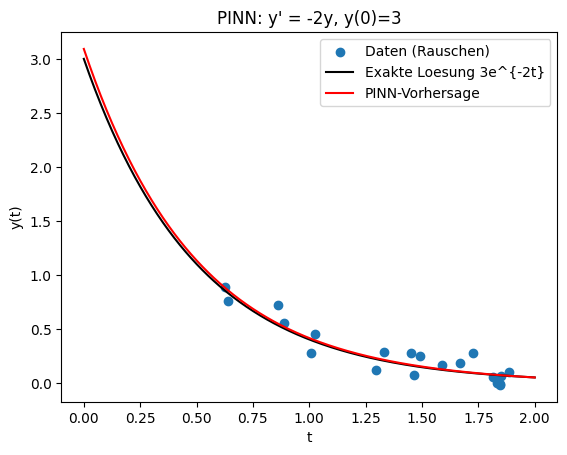

In [31]:
# --- Plot ---
t_dense = np.linspace(0.0, 2.0, 400).reshape(-1, 1).astype(np.float32)
y_exact_dense = 3.0 * np.exp(-2.0 * t_dense[:, 0])

with torch.no_grad():
    y_pred_dense = model(torch.from_numpy(t_dense).to(device)).cpu().numpy()[:, 0]

plt.figure()
plt.scatter(t_np, y_noisy_np, label="Daten (Rauschen)", color="C0")
plt.plot(t_dense[:, 0], y_exact_dense, label="Exakte Loesung 3e^{-2t}", color="black")
plt.plot(t_dense[:, 0], y_pred_dense, label="PINN-Vorhersage", color="red")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.title("PINN: y' = -2y, y(0)=3")
plt.show()